In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a synthetic dataset
np.random.seed(42)
num_entries = 150

data = {
    'Age': np.random.randint(22, 65, num_entries),
    'Salary': np.random.randint(30000, 150000, num_entries),
    'Experience_Years': np.random.randint(0, 40, num_entries),
    'Working_Hours_per_Week': np.random.randint(20, 60, num_entries),
    'Satisfaction_Score': np.random.uniform(1.0, 5.0, num_entries)
}

df = pd.DataFrame(data)

# Add some correlation between Experience_Years and Salary, and Age and Experience_Years
df['Salary'] = df['Salary'] + (df['Experience_Years'] * 2000)
df['Age'] = df['Age'] + (df['Experience_Years'] * 0.5)

# Ensure Age remains within a reasonable range after adjustment
df['Age'] = df['Age'].apply(lambda x: min(x, 65))

# Ensure Salary remains positive
df['Salary'] = df['Salary'].apply(lambda x: max(x, 30000))

# Round Satisfaction_Score for better presentation
df['Satisfaction_Score'] = df['Satisfaction_Score'].round(2)

print("Synthetic dataset created:")
display(df.head())

# Save the dataset to a CSV file
df.to_csv('synthetic_employee_data.csv', index=False)
print('\nDataset saved as synthetic_employee_data.csv')

# i. Connect to the Dataset:
# Load using pandas.read_csv() (already loaded, but demonstrating the step)
# df = pd.read_csv('synthetic_employee_data.csv')
# print('\nDataset loaded from CSV.')

# Display summary statistics for all continuous variables.
print('\nSummary Statistics for Continuous Variables:')
display(df.describe())

Synthetic dataset created:


,Age,Salary,Experience_Years,Working_Hours_per_Week,Satisfaction_Score
0,64.0,110044,8,58,1.93
1,65.0,140557,34,24,3.33
2,45.0,115080,18,41,4.45
3,65.0,169556,15,48,4.52
4,30.0,36693,2,22,1.95



Dataset saved as synthetic_employee_data.csv

Summary Statistics for Continuous Variables:


,Age,Salary,Experience_Years,Working_Hours_per_Week,Satisfaction_Score
count,150.000000,150.000000,150.00000,150.000000,150.000000
mean,52.176667,135189.206667,21.38000,40.706667,2.986733
std,11.938058,41641.290864,11.34136,11.258731,1.110560
min,23.000000,32049.000000,0.00000,20.000000,1.050000
25%,42.500000,104917.500000,13.25000,31.000000,2.062500
50%,54.250000,136923.000000,23.00000,42.000000,2.920000
75%,65.000000,169428.250000,31.75000,50.750000,3.957500
max,65.000000,212081.000000,39.00000,59.000000,4.980000


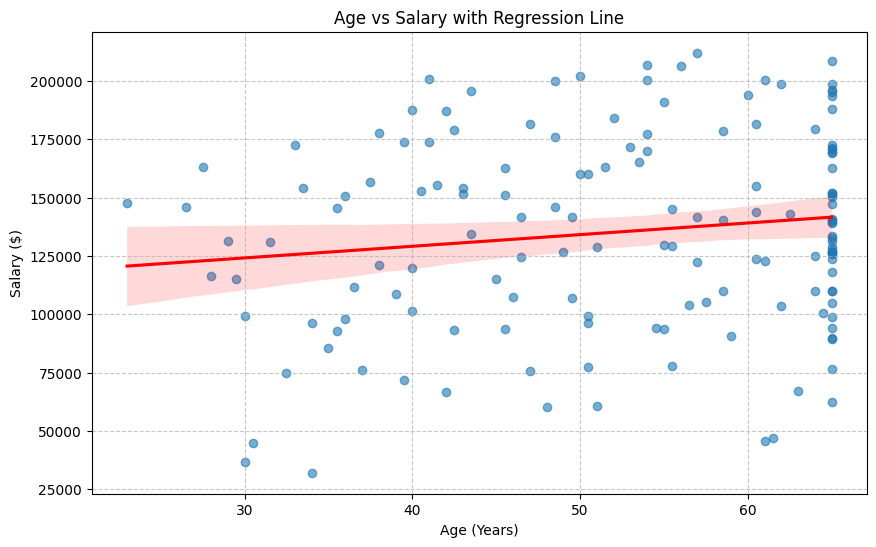

In [ ]:
# Age vs Salary using Scatterplot with Regression/Fit Line
plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='Salary', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Age vs Salary with Regression Line')
plt.xlabel('Age (Years)')
plt.ylabel('Salary ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

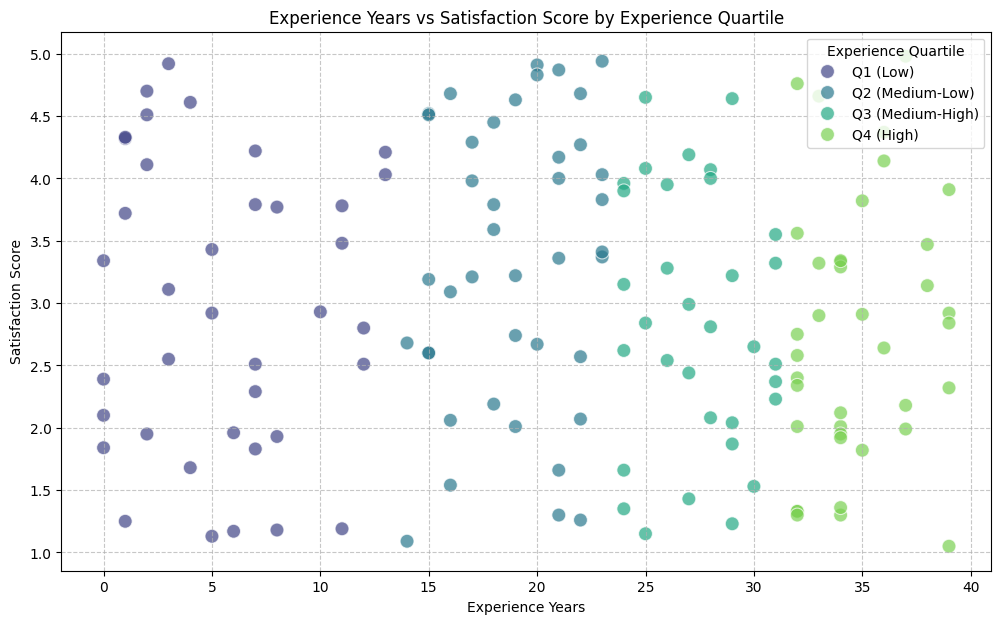

In [ ]:
# Experience_Years vs Satisfaction_Score using sns.scatterplot() with hue based on quartile groupings.
# Create quartile groupings for Experience_Years
df['Experience_Years_Quartile'] = pd.qcut(
    df['Experience_Years'],
    q=4,
    labels=['Q1 (Low)', 'Q2 (Medium-Low)', 'Q3 (Medium-High)', 'Q4 (High)']
)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Experience_Years',
    y='Satisfaction_Score',
    hue='Experience_Years_Quartile',
    data=df,
    palette='viridis',
    s=100, # size of points
    alpha=0.7 # transparency
)
plt.title('Experience Years vs Satisfaction Score by Experience Quartile')
plt.xlabel('Experience Years')
plt.ylabel('Satisfaction Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Experience Quartile')
plt.show()

Pearson Correlation Matrix:


,Age,Salary,Experience_Years,Working_Hours_per_Week,Satisfaction_Score
Age,1.000000,0.143114,0.408896,-0.043678,-0.014771
Salary,0.143114,1.000000,0.513660,-0.167577,0.074355
Experience_Years,0.408896,0.513660,1.000000,-0.093940,-0.079349
Working_Hours_per_Week,-0.043678,-0.167577,-0.093940,1.000000,-0.049894
Satisfaction_Score,-0.014771,0.074355,-0.079349,-0.049894,1.000000


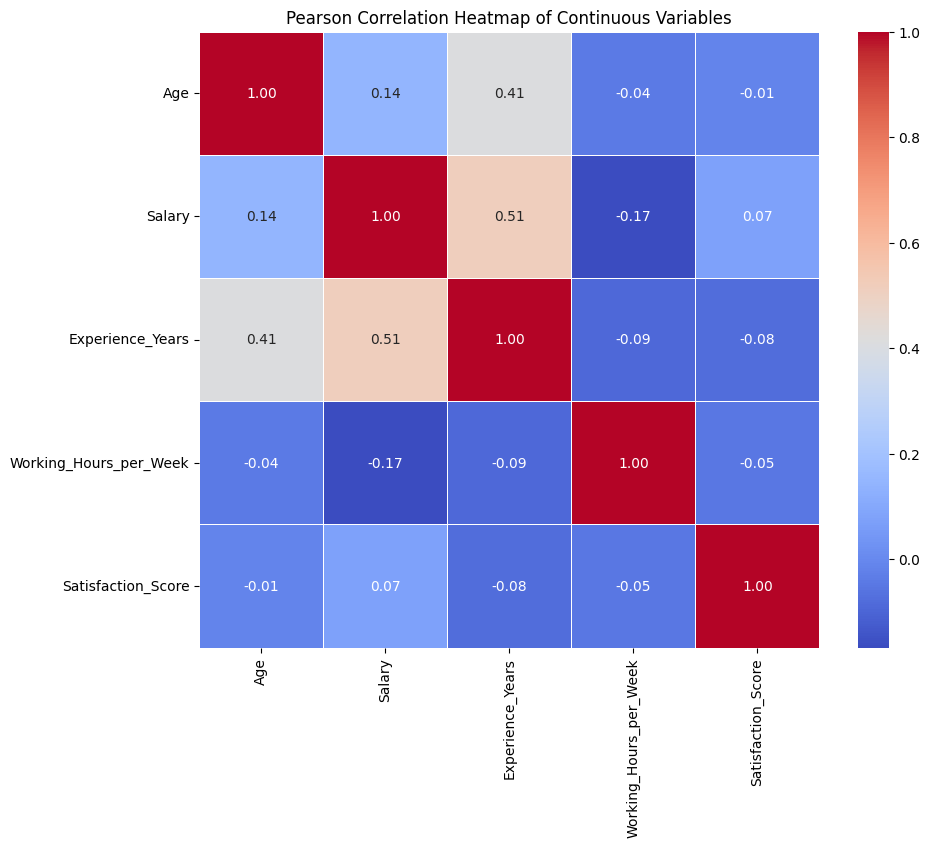

In [ ]:
# Compute the Pearson correlation between continuous variables
continuous_vars = ['Age', 'Salary', 'Experience_Years', 'Working_Hours_per_Week', 'Satisfaction_Score']
pearson_corr = df[continuous_vars].corr(method='pearson')
print('Pearson Correlation Matrix:')
display(pearson_corr)

# Use a heatmap (sns.heatmap()) to show Pearson correlation values
plt.figure(figsize=(10, 8))
sns.heatmap(
    pearson_corr,
    annot=True, # Show the correlation values on the heatmap
    cmap='coolwarm', # Color map
    fmt=".2f", # Format annotation to two decimal places
    linewidths=.5 # Add lines between cells
)
plt.title('Pearson Correlation Heatmap of Continuous Variables')
plt.show()


Spearman Correlation Matrix:


,Age,Salary,Experience_Years,Working_Hours_per_Week,Satisfaction_Score
Age,1.000000,0.103908,0.393341,-0.051458,-0.013358
Salary,0.103908,1.000000,0.484596,-0.171567,0.054430
Experience_Years,0.393341,0.484596,1.000000,-0.091469,-0.092217
Working_Hours_per_Week,-0.051458,-0.171567,-0.091469,1.000000,-0.052780
Satisfaction_Score,-0.013358,0.054430,-0.092217,-0.052780,1.000000


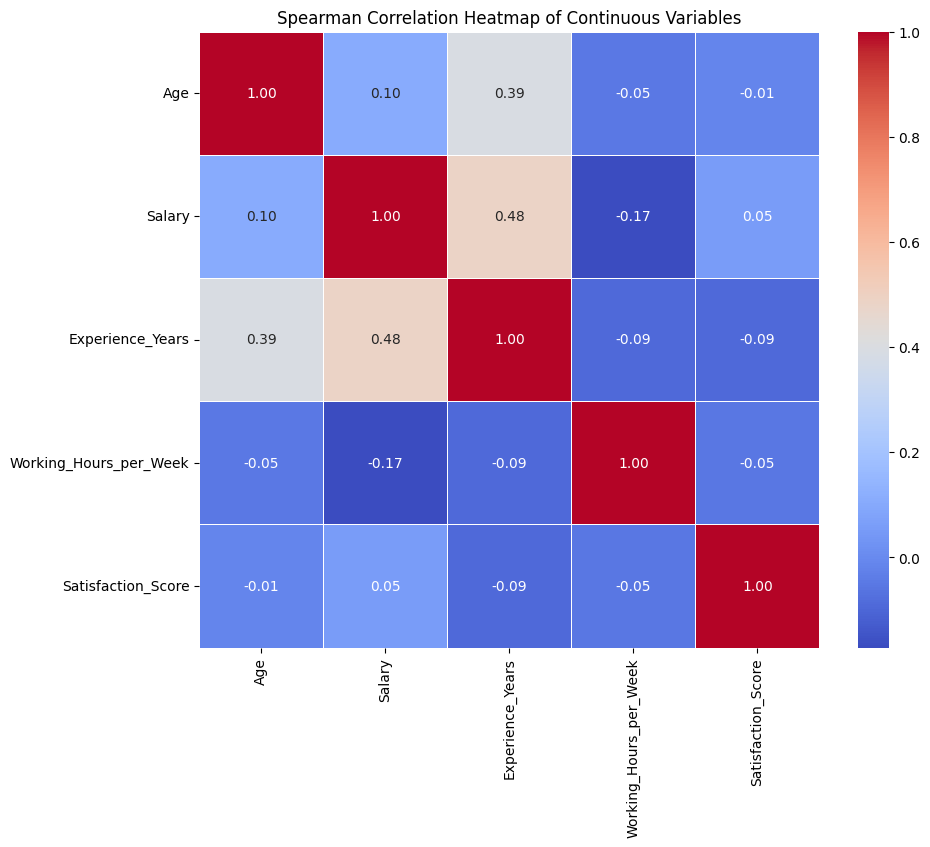

In [ ]:
# Compute the Spearman correlation between continuous variables
spearman_corr = df[continuous_vars].corr(method='spearman')
print('\nSpearman Correlation Matrix:')
display(spearman_corr)

# Use a heatmap (sns.heatmap()) to show Spearman correlation values
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Spearman Correlation Heatmap of Continuous Variables')
plt.show()